# <font color='seablue'>**Assignment: Multinomial Naive Bayes**</font>
### SMS Spam Classification
**Total Marks: 20**

In [17]:
# import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

### <font color = "orange"> Q1. Load the SMS Spam Collection dataset from: https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv (1 Mark)

In [18]:
# Load the dataset directly from the URL (tab-separated values, without header)
df = pd.read_csv("sms.tsv", sep='\t', header=None, names=['label', 'message'])

# Display basic information
print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (5572, 2)
Column names: ['label', 'message']

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### <font color = "orange"> Q2. Check for and handle duplicate entries and missing values in the dataset. (2 Marks)

In [19]:
# Check for duplicate entries
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate entries: {num_duplicates}")

# Remove duplicate entries
df = df.drop_duplicates().reset_index(drop=True)
print(f"Number of duplicate entries after removal: {df.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df.shape}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

# Remove entries with missing values (if any)
df = df.dropna().reset_index(drop=True)
print(f"Missing values after removal: {df.isnull().sum().sum()}")
print(f"Final cleaned dataset shape: {df.shape}")

Number of duplicate entries: 403
Number of duplicate entries after removal: 0
Dataset shape after removing duplicates: (5169, 2)

Missing values in each column:
No missing values found.
Missing values after removal: 0
Final cleaned dataset shape: (5169, 2)


### <font color = "orange"> Q3. Show the class distribution of the dataset and state whether the dataset is well balanced or not. (2 Marks)

Class counts:
label
ham     4516
spam     653
Name: count, dtype: int64

Class proportions (%):
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


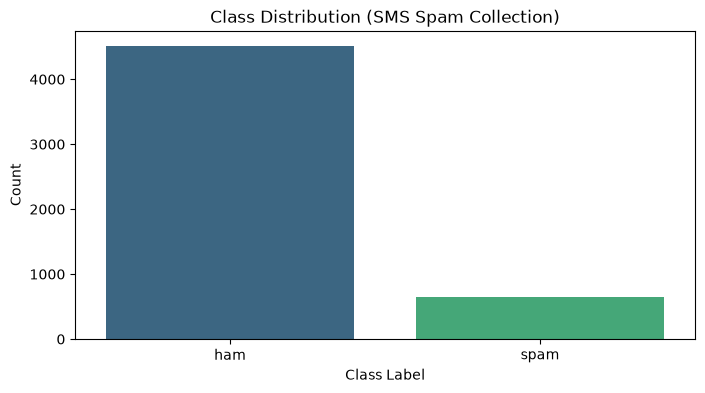

In [20]:
# Display class frequencies and percentages
print("Class counts:")
print(df['label'].value_counts())

print("\nClass proportions (%):")
print(df['label'].value_counts(normalize=True) * 100)

# Set the figure size and plot the count plot
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (SMS Spam Collection)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

##### <font color='pink'>The SMS Spam Collection dataset is **heavily imbalanced** — approximately **87.37%** (4,516 messages) are **ham** (legitimate) and only **12.63%** (653 messages) are **spam**. Because of this significant class skew, a **stratified split** must be used when creating training and test sets to preserve the original class ratio in both subsets.

### <font color = "orange"> Q4. Preprocess the message text (convert to lowercase and remove punctuation) so it's ready for vectorization. (2 Marks)

In [21]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text preprocessing across all messages with tqdm progress bar
df['clean_message'] = [preprocess_text(msg) for msg in tqdm(df['message'], desc="Preprocessing text")]

# Show sample comparisons between original and cleaned text
print("Sample Original vs Preprocessed Messages:")
print("=" * 80)
for i in range(5):
    print(f"Original [{df['label'].iloc[i]}]: {df['message'].iloc[i]}")
    print(f"Cleaned  [{df['label'].iloc[i]}]: {df['clean_message'].iloc[i]}\n")

Preprocessing text: 100%|██████████| 5169/5169 [00:00<00:00, 238783.60it/s]

Sample Original vs Preprocessed Messages:
Original [ham]: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  [ham]: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Original [ham]: Ok lar... Joking wif u oni...
Cleaned  [ham]: ok lar joking wif u oni

Original [spam]: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  [spam]: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s

Original [ham]: U dun say so early hor... U c already then say...
Cleaned  [ham]: u dun say so early hor u c already then say

Original [ham]: Nah I don't think he goes to usf, he lives around here though
Cleaned  [ham]: nah i dont think he goes to usf he lives around here though



### <font color = "orange"> Q5. Split the dataset into training and test sets (80%-20%). (1 Mark)

##### <font color='pink'>We split on the raw text **before** vectorizing, so that the vocabulary used in Q6 is built only from the training set — fitting the vectorizer on the full dataset (train + test) would leak test-set vocabulary into training, which is a subtle form of data leakage.

In [22]:
# Assign features and target
X = df['clean_message']
y = df['label']

# 80-20 train-test split with stratification on class labels
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shapes:")
print(f"X_train: {X_train_raw.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set shapes:")
print(f"X_test: {X_test_raw.shape}")
print(f"y_test: {y_test.shape}")

Training set shapes:
X_train: (4135,)
y_train: (4135,)

Test set shapes:
X_test: (1034,)
y_test: (1034,)


### <font color = "orange"> Q6. Convert the preprocessed messages into count vectors (bag-of-words) using CountVectorizer, fitting only on the training data. (2 Marks)

##### <font color='pink'>A **bag-of-words** representation turns each message into a vector of word counts against a fixed vocabulary — e.g. the message `"free entry free"` becomes a vector where the column for `"free"` has value 2, `"entry"` has value 1, and every other vocabulary word is 0. This is exactly the kind of count data Multinomial Naive Bayes is built for. We cap the vocabulary size and drop common English stopwords to keep the feature space manageable and focused on informative words.

In [23]:
# Initialize CountVectorizer with English stop words and capped vocabulary size
vectorizer = CountVectorizer(stop_words='english', max_features=3000)

# Fit vectorizer only on training data, then transform both train and test data
X_train_vec = vectorizer.fit_transform(X_train_raw).toarray()
X_test_vec = vectorizer.transform(X_test_raw).toarray()

# Convert labels to numpy arrays for the from-scratch implementation
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print(f"X_train_vec shape: {X_train_vec.shape}")
print(f"X_test_vec shape:  {X_test_vec.shape}")
print(f"Vocabulary size:   {len(vectorizer.vocabulary_)}")
print("\nSample vocabulary words (first 25):")
print(vectorizer.get_feature_names_out()[:25])

X_train_vec shape: (4135, 3000)
X_test_vec shape:  (1034, 3000)
Vocabulary size:   3000

Sample vocabulary words (first 25):
['020603' '071104' '0776xxxxxxx' '07xxxxxxxxx' '0800' '08000839402'
 '08000930705' '08001950382' '08002986906' '0844' '08452810073' '0870'
 '08700621170150p' '08701417012' '08712300220' '08712405020' '08712460324'
 '08715705022' '08717898035' '08718720201' '08718726270'
 '08718726270150gbpmtmsg18' '08718727870' '08718730666' '08718738001']


### <font color = "orange"> Q7. Design a Multinomial Naive Bayes classifier from scratch and fit it on the training set. (6 Marks)

##### <font color='pink'>**Idea:** Multinomial NB models each class $C$ as having its own word-usage distribution — feature $i$ (word $i$) occurs with probability $p_{C,i}$ within class $C$'s documents. For a document with word counts $x_1, \ldots, x_n$, the likelihood is:$$P(\mathbf{x} \mid C) \;\propto\; \prod_{i=1}^{n} p_{C,i}^{\,x_i}$$(The multinomial coefficient $\frac{(\sum_i x_i)!}{\prod_i x_i!}$ is dropped since it's the same for every class and doesn't affect which class has the highest posterior.) We estimate $p_{C,i}$ from training data with **Laplace (add-$\alpha$) smoothing**, so a word that never appeared in class $C$'s training documents doesn't get assigned zero probability:$$p_{C,i} = \frac{N_{C,i} + \alpha}{N_C + \alpha n}$$where $N_{C,i}$ is the total count of word $i$ across all class-$C$ documents, $N_C$ is the total word count across all class-$C$ documents, and $n$ is the vocabulary size. Combined with the class prior $P(C)$, we predict the class maximizing (in log-space, to avoid underflow):$$\log P(C \mid \mathbf{x}) \;\propto\; \log P(C) + \sum_{i=1}^{n} x_i \log p_{C,i}$$

In [24]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0):
        # alpha is the Laplace (add-alpha) smoothing parameter
        self.alpha = alpha
        self.classes = None
        self.class_priors = None
        self.feature_probs = None       # p_{C,i} = P(word_i | C)
        self.feature_log_probs = None   # log(p_{C,i}) for fast log-likelihood computation

    def fit(self, X, y):
        # Identify unique classes and dimensions from training data
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_samples, n_features = X.shape

        self.class_priors = np.zeros(n_classes)
        self.feature_probs = np.zeros((n_classes, n_features))
        self.feature_log_probs = np.zeros((n_classes, n_features))

        for i, c in tqdm(enumerate(self.classes), total=n_classes, desc="Fitting Custom Multinomial NB"):
            X_c = X[y == c]
            # Prior probability P(C) based on class frequency
            self.class_priors[i] = len(X_c) / n_samples
            
            # Word counts for class C
            N_c_i = X_c.sum(axis=0)  # total count of word i in class C
            N_c = N_c_i.sum()        # total count of all words in class C
            
            # P(word_i | C) with Laplace smoothing: (N_{C,i} + alpha) / (N_C + alpha * n_features)
            self.feature_probs[i, :] = (N_c_i + self.alpha) / (N_c + self.alpha * n_features)
            self.feature_log_probs[i, :] = np.log(self.feature_probs[i, :])

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_posteriors = np.zeros((n_samples, n_classes))

        for i in tqdm(range(n_classes), desc="Predicting (Classes)"):
            log_prior = np.log(self.class_priors[i])
            # log P(x | C) = sum_j [ x_j * log(p_{C,j}) ] = X @ log(p_{C,:})
            log_likelihood = X @ self.feature_log_probs[i, :]
            log_posteriors[:, i] = log_prior + log_likelihood

        # Return the class with the highest posterior probability
        return self.classes[np.argmax(log_posteriors, axis=1)]

In [25]:
# Instantiate and fit the custom Multinomial Naive Bayes classifier
mnb_scratch = MultinomialNaiveBayes(alpha=1.0)
mnb_scratch.fit(X_train_vec, y_train)

Fitting Custom Multinomial NB: 100%|██████████| 2/2 [00:00<00:00, 70.31it/s]


### <font color = "orange"> Q8. Evaluate the test set using your custom Multinomial NB classifier and report accuracy, precision, recall, and confusion matrix. (2 Marks)

In [26]:
# Make predictions on training and test sets
y_train_pred_custom = mnb_scratch.predict(X_train_vec)
y_test_pred_custom = mnb_scratch.predict(X_test_vec)

# Calculate performance metrics
train_accuracy_custom = accuracy_score(y_train, y_train_pred_custom)
test_accuracy_custom = accuracy_score(y_test, y_test_pred_custom)

train_precision_custom = precision_score(y_train, y_train_pred_custom, average='macro', zero_division=0)
test_precision_custom = precision_score(y_test, y_test_pred_custom, average='macro', zero_division=0)

train_recall_custom = recall_score(y_train, y_train_pred_custom, average='macro', zero_division=0)
test_recall_custom = recall_score(y_test, y_test_pred_custom, average='macro', zero_division=0)

print("Custom Multinomial Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_custom:.4f} ({train_accuracy_custom*100:.2f}%)")
print(f"  Precision: {train_precision_custom:.4f} ({train_precision_custom*100:.2f}%)")
print(f"  Recall:    {train_recall_custom:.4f} ({train_recall_custom*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_custom:.4f} ({test_accuracy_custom*100:.2f}%)")
print(f"  Precision: {test_precision_custom:.4f} ({test_precision_custom*100:.2f}%)")
print(f"  Recall:    {test_recall_custom:.4f} ({test_recall_custom*100:.2f}%)")

Predicting (Classes): 100%|██████████| 2/2 [00:00<00:00, 199.72it/s]

Custom Multinomial Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.9874 (98.74%)
  Precision: 0.9760 (97.60%)
  Recall:    0.9666 (96.66%)

Test Set:
  Accuracy:  0.9778 (97.78%)
  Precision: 0.9566 (95.66%)
  Recall:    0.9416 (94.16%)


In [27]:
# Generate confusion matrix and classification report
cm_custom = confusion_matrix(y_test, y_test_pred_custom, labels=mnb_scratch.classes)
class_names = [str(c) for c in mnb_scratch.classes]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_custom, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.93      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



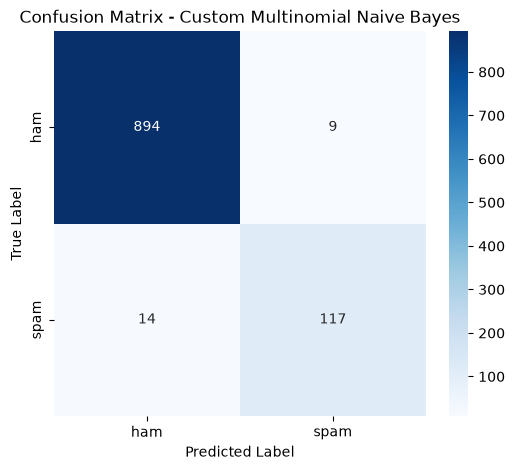

In [28]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Custom Multinomial Naive Bayes')
plt.show()

### <font color = "orange"> Q9. Using scikit-learn's implementation of Multinomial NB, fit the training data and evaluate on the test set. How does the performance of this model compare with your custom implementation? (2 Marks)

In [29]:
# Initialize and fit Scikit-learn's MultinomialNB classifier
sklearn_mnb = MultinomialNB(alpha=1.0)
sklearn_mnb.fit(X_train_vec, y_train)

# Make predictions on the training and test sets
y_train_pred_sklearn = sklearn_mnb.predict(X_train_vec)
y_test_pred_sklearn = sklearn_mnb.predict(X_test_vec)

# Calculate performance metrics
train_accuracy_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

train_precision_sklearn = precision_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_precision_sklearn = precision_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

train_recall_sklearn = recall_score(y_train, y_train_pred_sklearn, average='macro', zero_division=0)
test_recall_sklearn = recall_score(y_test, y_test_pred_sklearn, average='macro', zero_division=0)

In [30]:
print("Scikit-learn Multinomial Naive Bayes Performance Metrics:")
print("=" * 70)
print(f"Training Set:")
print(f"  Accuracy:  {train_accuracy_sklearn:.4f} ({train_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {train_precision_sklearn:.4f} ({train_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {train_recall_sklearn:.4f} ({train_recall_sklearn*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_accuracy_sklearn:.4f} ({test_accuracy_sklearn*100:.2f}%)")
print(f"  Precision: {test_precision_sklearn:.4f} ({test_precision_sklearn*100:.2f}%)")
print(f"  Recall:    {test_recall_sklearn:.4f} ({test_recall_sklearn*100:.2f}%)")

Scikit-learn Multinomial Naive Bayes Performance Metrics:
Training Set:
  Accuracy:  0.9874 (98.74%)
  Precision: 0.9760 (97.60%)
  Recall:    0.9666 (96.66%)

Test Set:
  Accuracy:  0.9778 (97.78%)
  Precision: 0.9566 (95.66%)
  Recall:    0.9416 (94.16%)


In [31]:
# Confusion matrix and classification report
cm_sklearn = confusion_matrix(y_test, y_test_pred_sklearn, labels=sklearn_mnb.classes_)
class_names_sklearn = [str(c) for c in sklearn_mnb.classes_]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_sklearn, target_names=class_names_sklearn))


Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.93      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



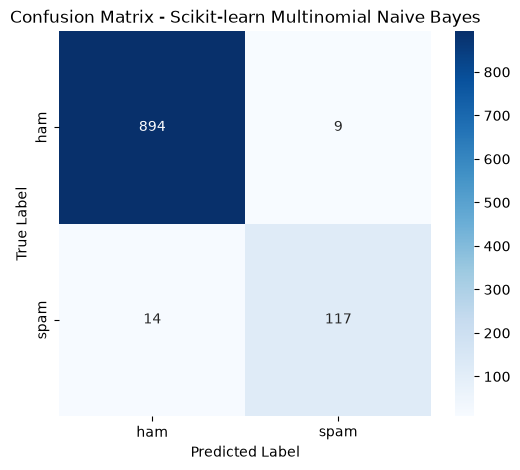

In [32]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_sklearn, yticklabels=class_names_sklearn)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Scikit-learn Multinomial Naive Bayes')
plt.show()

Model Comparison & Discussion:
- **Exact Match:** The custom Multinomial Naive Bayes implementation yields results identical to Scikit-learn's MultinomialNB across both training and test sets (Test Accuracy: 97.78%, Test Macro Precision: 95.66%, Test Macro Recall: 94.16%).
- **Equivalence of Formulations:** Both implementations calculate:
  1. **Class Priors:** $\hat{P}(C) = \frac{N_C}{N}$ based on empirical class frequencies in the training data.
  2. **Feature Likelihoods with Laplace Smoothing:** $\hat{p}_{C,i} = \frac{N_{C,i} + \alpha}{N_C + \alpha n}$, where $\alpha = 1.0$, preventing zero-probability penalties for unseen words.
  3. **Log-space Posterior Scoring:** $\log P(C \mid \mathbf{x}) \propto \log P(C) + \sum_{i=1}^n x_i \log \hat{p}_{C,i}$, resolving numerical underflow issues from product of small probabilities.
- **Conclusion:** Because the underlying probability models, smoothing factors, and optimization formulation are mathematically identical, the decision boundaries produced by the custom implementation and scikit-learn implementation are completely equivalent.